In [1]:
import QIBA
from processing_functions import AnalysisPar
from processing_functions import QIBAPlotPar

In [ ]:
# Setup Processing Parameters
kasai_kernel_WL         = 3     # kernel size for particle motion estimation
axial_process_depth_mm  = "push_focus" # either "push_focus" or fixed process depth (mm)
dof_average_mm          = 1     # depth of field to average (mm)
        
min_lat_mm              = 4   # min lateral position (mm) to start analysis
max_lat_mm              = 16  # max lateral position (mm) to end analysis
min_time_ms             = -15 # minimum time (ms) to zero-pad before push
max_time_ms             = 40  # maximum time (ms) to use in analysis
rolloff_time_ms         = 15  # time (ms) for rolloff at early and late times
n_steps_to_remove       = 2   # number of reverb steps to remove
LPF_cutoff_kHz          = 1   # low-pass filter cutoff frequency (kHz)
desired_PRF_kHz         = 20  # desired PRF (kHz) after upsampling in time 
min_phasevel_freq_Hz    = 20  # frequencies (Hz) for phase velocity measurements
max_phasevel_freq_Hz    = 500
phasevel_step_Hz        = 10
SWS_est_method          = "radonsum" # or "ttp"

# Parameters for plotting and saving outputs
max_plot_speed      = 6;      # maximum speed for gSWS and phVel plots
max_plot_freq       = 550;    # max frequency (Hz) for plot
frac_error_bar      = 0.3;    # fixed fraction for error bars
CI_factor           = 1.96;   # confidence interval for error bars
fmax                = 550;    # maximum frequency (Hz) to plot
rmin                = 0.004;  # minimum lateral position (m) for low freq cutoff
kr_threshold        = 1.5;    # kr threshold for low freq cutoff
max_speed           = 8;      # max speed for "good" result
th_factor           = 2;      # Vel accept range = +/- thfactor * std
min_valid_gsws      = 0.5;    # minimum group speed where results are valid
max_valid_gsws      = 6;      # maximum group speed where results are valid

Total Acquisitions Found: 10
Processing Acquisition...:


  0%|          | 0/10 [00:00<?, ?it/s]

using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum
using radon sum


/hpc/group/ultrasound/ss1294/repos/qiba_repo/python_processing/QIBAOutput.py:230: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


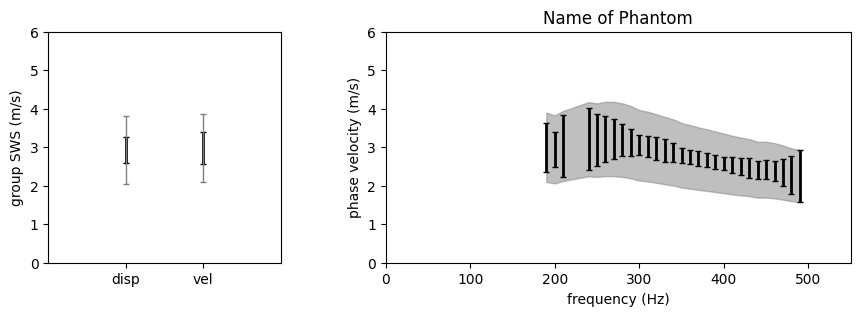

In [ ]:
save_directory = "name_of_directory"
phantom_id     = 'Name of Phantom';  # phantom ID string

analysis_params = AnalysisPar.AnalysisPar(save_directory, kasai_kernel_WL, axial_process_depth_mm,
                                          dof_average_mm, min_lat_mm,
                                          max_lat_mm, min_time_ms, max_time_ms,
                                          rolloff_time_ms, n_steps_to_remove,
                                          LPF_cutoff_kHz, desired_PRF_kHz,
                                          min_phasevel_freq_Hz, max_phasevel_freq_Hz,
                                          phasevel_step_Hz,SWS_est_method)
plot_params = QIBAPlotPar.QIBAPlotPar(phantom_id, max_plot_speed, max_plot_freq, frac_error_bar, CI_factor, 
                                        fmax, rmin, kr_threshold, max_speed, th_factor, max_valid_gsws, 
                                        min_valid_gsws)

out = QIBA.Analyze_All_Acquisitions(save_directory, analysis_params, plot_params)

After processing all of the acquisitions, information about each acquisition will be stored in the output variable, each marked with their file timestamp:

In [4]:
# output.include_dict
print('disp_speeds')
print(out.filtered_disp_gSWSs)

print('vel speeds')
print(out.filtered_vel_gSWSs)


disp_speeds
[2.85982064        nan        nan        nan 2.71861265        nan
 2.7349281         nan        nan        nan        nan        nan
 3.17531729 2.84039687 3.02605427 2.98476458 3.22734921 2.7913031
        nan        nan]
vel speeds
[2.81505814 2.29695507 3.04648068 2.91825266 2.96897957        nan
 3.01288217 3.1522455  2.99125983 3.03442912 3.03955471        nan
 3.10547752 2.91327757 3.31096792 2.90386474 3.16014881 2.96576995
        nan        nan]


The `[True, True]` indicates that shear waves propagating in both the leftward and rightward directions are included in the final reported results.

To exclude a single side of an acquisition, mark it as False in the include_dict dictionary. To exclude an entire acquisition, mark both sides as False:

In [ ]:
acqs = out.acq_timestamps
out.include_dict

out.show_spacetime_plot_for_acq

# Mark acq 3 as entirely excluded:
out.include_dict[acqs[6]] = [False, False]

# Mark the leftward propagating wave in acq 7 as excluded:
out.include_dict[acqs[6]] = [False, True]

# Re-process SWSs and re-generate final outputs:
QIBA.filter_SWSs_and_display_final_outputs(out, plot_params)

In [ ]:
out.show_spacetime_plot_for_acq(acqs[6])

One can also show the displacement data planes, and change the colorbar limits:

In [ ]:
out.show_spacetime_plot_for_acq(acqs[1], plane_type='displacement', clim=[-3, 3])

There is an additional helper function that can be used to generate gifs of the displacement data, which can be seen below:

In [ ]:
gif_obj = out.generate_displacement_gif_for_acq(acqs[0], clim=[-10, 10])
gif_obj